# Anisotropic orientation optimization
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/shell/orientation.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/optimization/shell/orientation.ipynb)

In [1]:
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

from torchfem import Shell
from torchfem.materials import OrthotropicElasticityPlaneStress
from torchfem.mesh import rect_tri
from torchfem.rotations import planar_rotation

torch.set_default_dtype(torch.float64)

In [2]:
G_t = 10000.0 / (2.0 * (1 + 0.3))
mat = OrthotropicElasticityPlaneStress(
    E_1=100000.0, E_2=10000.0, nu_12=0.1, G_12=5000.0
)

In [3]:
# Parameters
L = 100.0
F = -10.0
Zm = 100.0

# Define plate
nodes, elements = rect_tri(9, 9, 0.5 * L, 0.5 * L, variant="zigzag")
nodes = torch.hstack([nodes, torch.zeros((len(nodes), 1))])

# Create Shell model
plate = Shell(nodes, elements, mat, transverse_G=[G_t, G_t])

# Boundaries
bottom = nodes[:, 1] < 0.01
left = nodes[:, 0] < 0.01

# Boundary conditions
plate.forces[0, 2] = F
plate.constraints[-1] = True
plate.constraints[left, 0] = True
plate.constraints[left, 4] = True
plate.constraints[left, 5] = True
plate.constraints[bottom, 1] = True
plate.constraints[bottom, 3] = True
plate.constraints[bottom, 5] = True

# Solve
u, f, σ, _, _ = plate.solve()


plate.plot(
    u[:, 0:3],
    node_property={"u": torch.linalg.norm(u[:, 0:3], dim=1)},
    mirror=(True, True, False),
)

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

# Optimization

## Target function is the strain energy

In [4]:
def target_function(phi):
    # Recompute stiffnesses due to changed orientations
    R = planar_rotation(phi)
    plate.material = mat.vectorize(plate.n_elem).rotate(R)
    # Solve
    u, f, _, _, _ = plate.solve(differentiable_parameters=phi)
    # Return compliance
    return torch.inner(u.ravel(), f.ravel())

## The optimization

In [5]:
phi = torch.zeros((len(plate.elements)), requires_grad=True)

optimizer = torch.optim.Adam([phi], lr=0.1)

energies = []

for _ in tqdm(range(100)):
    optimizer.zero_grad()
    objective = target_function(phi)
    energies.append(objective.detach().item())
    objective.backward()
    optimizer.step()

100%|██████████| 100/100 [00:04<00:00, 22.69it/s]


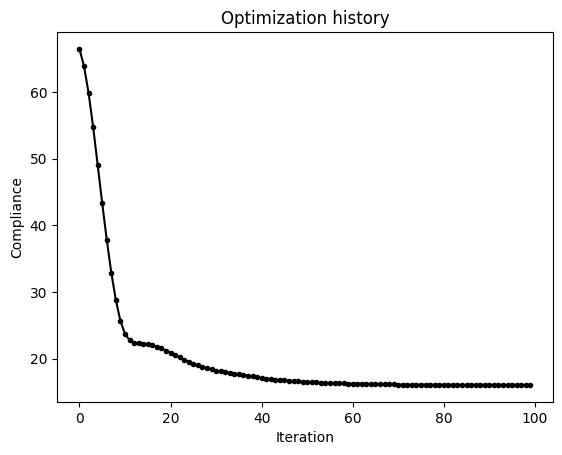

In [6]:
plt.plot(energies, ".-k")
plt.title("Optimization history")
plt.xlabel("Iteration")
plt.ylabel("Compliance")
plt.show()

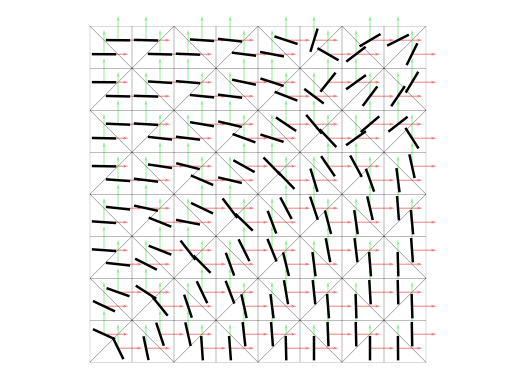

In [7]:
# Compute optimized displacements
u, f, _, _, _ = plate.solve()

# Compute properties
pos = plate.nodes
centers = pos[plate.elements, :].mean(dim=1)
loc_sys = plate.t
loc_dir = torch.stack([torch.cos(phi), -torch.sin(phi), torch.zeros_like(phi)]).T
dir = torch.einsum("...ij, ...j", plate.t.transpose(1, 2), loc_dir)

with torch.no_grad():
    # Plot local coordinate systems
    plt.quiver(
        centers[:, 0],
        centers[:, 1],
        loc_sys[:, 0, 0],
        loc_sys[:, 0, 1],
        width=0.002,
        color="lightcoral",
    )
    plt.quiver(
        centers[:, 0],
        centers[:, 1],
        loc_sys[:, 1, 0],
        loc_sys[:, 1, 1],
        width=0.002,
        color="lightgreen",
    )
    # Plot orientations
    plt.quiver(
        centers[:, 0],
        centers[:, 1],
        dir[:, 0],
        dir[:, 1],
        pivot="middle",
        headlength=0,
        headaxislength=0,
        headwidth=0,
        width=0.005,
        color="black",
    )
    # Plot elements
    pos = plate.nodes[:, 0:2]
    for element in plate.elements:
        x1 = [pos[node, 0] for node in element] + [pos[element[0], 0]]
        x2 = [pos[node, 1] for node in element] + [pos[element[0], 1]]
        plt.plot(x1, x2, color="black", linewidth=0.1)
    plt.axis("equal")
    plt.axis("off")
    plt.show()